# Unzip and Explore the Dataset

In [1]:
!apt-get install unrar -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [2]:
import zipfile
import os

In [13]:
zip_path = '/content/Dataset.rar'
extract_p = "/content/extract_p"

In [10]:
!unrar x '{zip_path}' {'extract_p'}/

Streaming output truncated to the last 5000 lines.
Extracting  extract_p/with_mask/1892.png                                  15%  OK 
Extracting  extract_p/with_mask/1893.png                                  15%  OK 
Extracting  extract_p/with_mask/1894.png                                  15%  OK 
Extracting  extract_p/with_mask/1895.png                                  15%  OK 
Extracting  extract_p/with_mask/1896.png                                  15%  OK 
Extracting  extract_p/with_mask/1897.png                                  15%  OK 
Extracting  extract_p/with_mask/1898.png                                  15%  OK 
Extracting  extract_p/with_mask/1899.png                                  15%  OK 
Extracting  extract_p/with_mask/19.png                                    15%  OK 
Extracting  extract_p/with_mask/190.png                                   15%  OK 
Extracting  extract_p/with_ma

# Count Images per Class

In [14]:
for class_name in os.listdir(extract_p):
    class_path = os.path.join(extract_p, class_name)
    num_images = len(os.listdir(class_path))
    print(f"{class_name}: {num_images} images")

without_mask: 2994 images
with_mask: 2994 images


# Preparing the Data for Training

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [16]:
data_dit = '/content/extract_p'
img_size = (128, 128)
batch_size = 32

In [17]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = .2,
    rotation_range = 20,
    zoom_range = 0.2,
    horizontal_flip = True
)

In [18]:
train_generator = train_datagen.flow_from_directory(
    data_dit,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary',
    subset = 'training'
)

Found 4792 images belonging to 2 classes.


In [20]:
val_generator = train_datagen.flow_from_directory(
    data_dit,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 1196 images belonging to 2 classes.


# Build the CNN Model

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,  Dropout

In [22]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(*img_size, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [26]:
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 227ms/step - accuracy: 0.7707 - loss: 0.4457 - val_accuracy: 0.9657 - val_loss: 0.1094
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 28s 189ms/step - accuracy: 0.9552 - loss: 0.1294 - val_accuracy: 0.9624 - val_loss: 0.1209
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 27s 182ms/step - accuracy: 0.9577 - loss: 0.1242 - val_accuracy: 0.9632 - val_loss: 0.1136
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 27s 183ms/step - accuracy: 0.9575 - loss: 0.1236 - val_accuracy: 0.9824 - val_loss: 0.0757
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 218ms/step - accuracy: 0.9656 - loss: 0.1022 - val_accuracy: 0.9808 - val_loss: 0.0754
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 28s 188ms/step - accuracy: 0.9746 - loss: 0.0856 - val_accuracy: 0.9816 - val_loss: 0.0638
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 220ms/step - accuracy: 0.9709 - loss: 0.0830 - val_accuracy: 0.9849 - val_loss: 0.0543
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 28s 183ms/step - accuracy: 0.9743 - loss: 0

In [27]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc:.2f}")
print(f"Validation Loss: {val_loss:.2f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - accuracy: 0.9842 - loss: 0.0470
Validation Accuracy: 0.99
Validation Loss: 0.04


In [28]:
import matplotlib.pyplot as plt

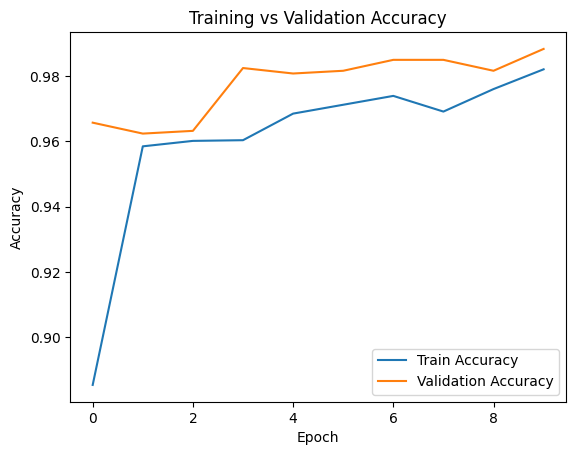

In [29]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

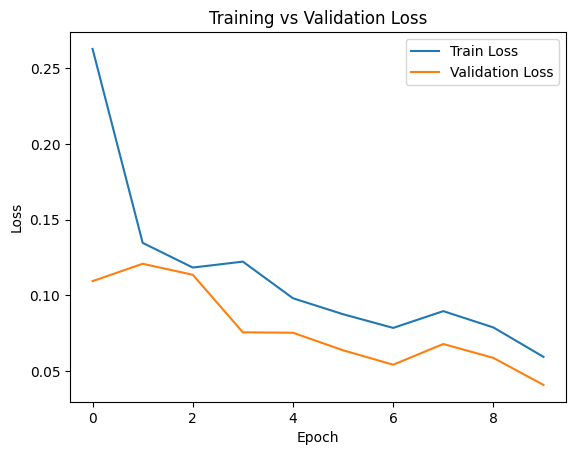

In [30]:
# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

In [31]:
model.save("face_mask_cnn_model.h5")

# Gradio App for Face Mask Detection

In [32]:
import gradio as gr
import numpy as np

In [33]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

In [34]:
model = load_model('/content/face_mask_cnn_model.h5')

In [35]:
class_labels = ["With Mask 😷", "Without Mask 😐"]

In [39]:
# Prediction function
def predict_mask(img):
    img = image.smart_resize(img, (128, 128))
    img_array = np.expand_dims(img / 255.0, axis=0)
    prediction = model.predict(img_array)[0][0]
    label = class_labels[0] if prediction < 0.5 else class_labels[1]
    return {class_labels[0]: 1 - prediction, class_labels[1]: prediction}, label

In [40]:
iface = gr.Interface(
    fn=predict_mask,
    inputs=gr.Image(type="numpy", label="Upload a face image"),
    outputs=[
        gr.Label(num_top_classes=2, label="Prediction Probabilities"),
        gr.Textbox(label="Final Prediction")
    ],
    title="😷 Face Mask Detection",
    description="Upload a face image and the model will predict whether the person is wearing a mask or not."
)


In [41]:
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0bc185bd7068952395.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
